In [1]:
import pandas as pd
import numpy as np


In [2]:
from google.colab import files
uploaded = files.upload()

Saving Online Retail.xlsx to Online Retail.xlsx


In [3]:
data = pd.read_excel('Online Retail.xlsx')

In [4]:
data['CustomerID'].nunique()

4372

In [5]:
data.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


### Seperating the Total Order with othere that were completed and with those which were canceled


In [6]:
df_cancled = data[data['InvoiceNo'].astype('str').str.startswith('C')].copy()
df_normal = data[~data['InvoiceNo'].astype('str').str.startswith('C')].copy()

### Seperating known and unknown(null customerID) customer from the oder that was completed

In [9]:
df_unknown = df_normal[df_normal['CustomerID'].isna()].copy()
df_known = df_normal[df_normal['CustomerID'].notna()].copy()

In [11]:
df_known.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [12]:
df_known.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,397924.000000,397924,397924.000000,397924.000000
mean,13.021823,2011-07-10 23:43:36.912475648,3.116174,15294.315171
min,1.000000,2010-12-01 08:26:00,0.000000,12346.000000
25%,2.000000,2011-04-07 11:12:00,1.250000,13969.000000
50%,6.000000,2011-07-31 14:39:00,1.950000,15159.000000
75%,12.000000,2011-10-20 14:33:00,3.750000,16795.000000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000
std,180.420210,NaN,22.096788,1713.169877


In [13]:
data = df_known

In [14]:
data.shape

(397924, 8)

In [15]:
data.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,397924.000000,397924,397924.000000,397924.000000
mean,13.021823,2011-07-10 23:43:36.912475648,3.116174,15294.315171
min,1.000000,2010-12-01 08:26:00,0.000000,12346.000000
25%,2.000000,2011-04-07 11:12:00,1.250000,13969.000000
50%,6.000000,2011-07-31 14:39:00,1.950000,15159.000000
75%,12.000000,2011-10-20 14:33:00,3.750000,16795.000000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000
std,180.420210,NaN,22.096788,1713.169877


### Handling the outlier using the 99th percentile

In [16]:
upper_q = data['Quantity'].quantile(0.99)
upper_p = data['UnitPrice'].quantile(0.99)
data['Quantity'] = data['Quantity'].clip(upper = upper_q)
data['UnitPrice'] = data['UnitPrice'].clip(upper = upper_p)

In [21]:
data.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,397924.000000,397924,397924.000000,397924.000000
mean,10.915941,2011-07-10 23:43:36.912475648,2.827416,15294.315171
min,1.000000,2010-12-01 08:26:00,0.000000,12346.000000
25%,2.000000,2011-04-07 11:12:00,1.250000,13969.000000
50%,6.000000,2011-07-31 14:39:00,1.950000,15159.000000
75%,12.000000,2011-10-20 14:33:00,3.750000,16795.000000
max,120.000000,2011-12-09 12:50:00,14.950000,18287.000000
std,18.081344,NaN,2.785750,1713.169877


In [23]:
data.isna().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [24]:
data['CustomerID'] = data['CustomerID'].astype(int)

### Calculating the total price of the order

In [27]:
data['Total Price'] = data['Quantity'] * data['UnitPrice']
data.to_csv('cleaned_data.csv', index=False)
files.download('cleaned_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Defining refrence date as 1 day after the latest transaction

In [28]:
snapshot_date = data['InvoiceDate'].max()+pd.DateOffset(days=1)

## RFM

In [29]:
rfm = data.groupby('CustomerID').agg(
    recency = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    frequency = ('InvoiceNo','nunique'),
    monetary = ('Total Price','sum')
).reset_index()

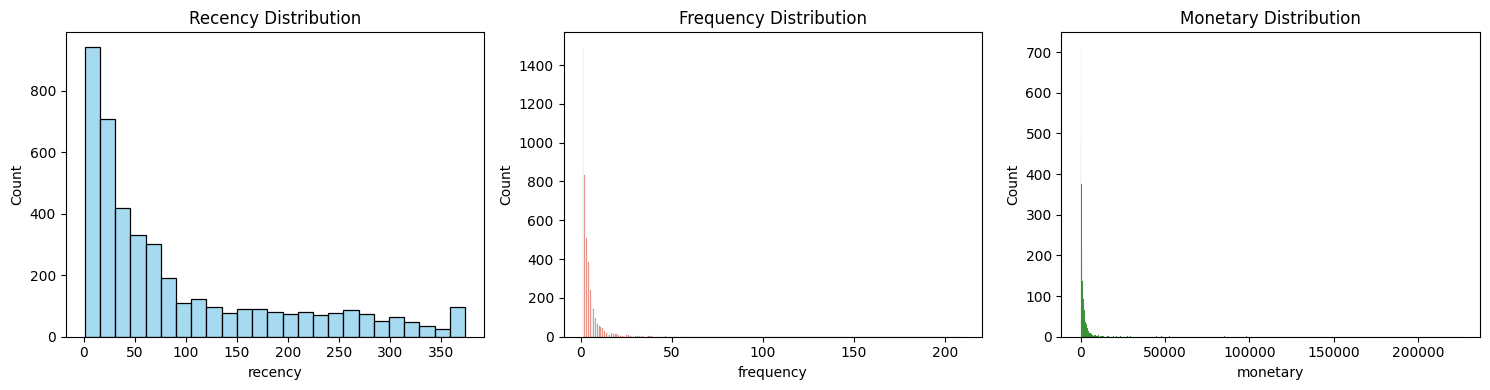

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(rfm['recency'],   ax=axes[0], color='skyblue')
sns.histplot(rfm['frequency'], ax=axes[1], color='salmon')
sns.histplot(rfm['monetary'],  ax=axes[2], color='green')
axes[0].set_title('Recency Distribution')
axes[1].set_title('Frequency Distribution')
axes[2].set_title('Monetary Distribution')
plt.tight_layout()
plt.show()

In [31]:
rfm['recency_log'] = np.log1p(rfm['recency'])
rfm['frequency_log'] = np.log1p(rfm['frequency'])
rfm['monetary_log'] = np.log1p(rfm['monetary'])

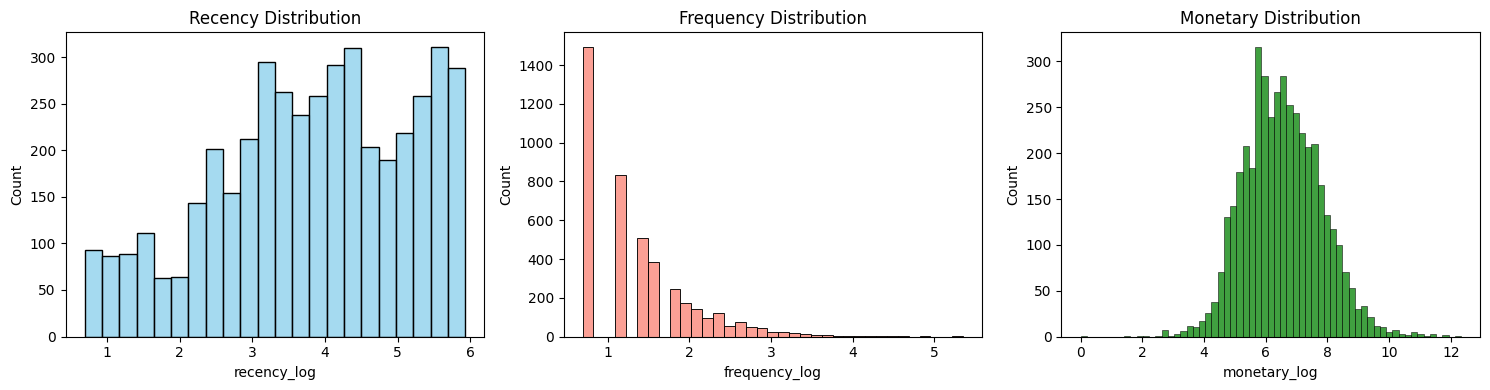

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(rfm['recency_log'],   ax=axes[0], color='skyblue')
sns.histplot(rfm['frequency_log'], ax=axes[1], color='salmon')
sns.histplot(rfm['monetary_log'],  ax=axes[2], color='green')
axes[0].set_title('Recency Distribution')
axes[1].set_title('Frequency Distribution')
axes[2].set_title('Monetary Distribution')
plt.tight_layout()
plt.show()

In [33]:
from sklearn.preprocessing import StandardScaler

In [34]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(
    rfm[['recency_log', 'frequency_log', 'monetary_log']]
)

In [35]:
from sklearn.cluster import KMeans
!pip install kneed
from kneed import KneeLocator

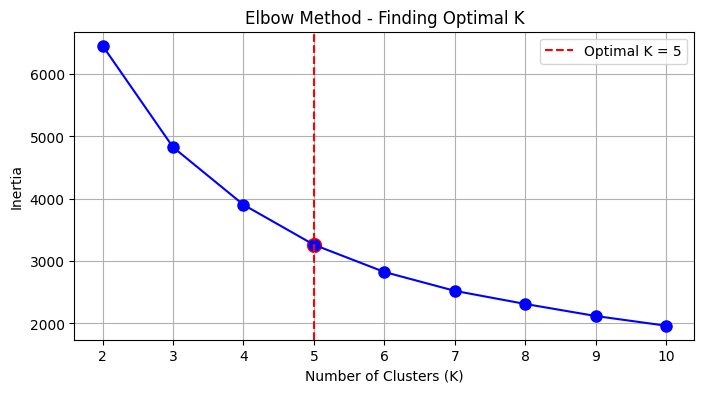

In [36]:
inertia = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

# Find elbow automatically
kneedle = KneeLocator(K_range, inertia, curve="convex", direction="decreasing")
optimal_k = kneedle.elbow

plt.figure(figsize=(8,4))
plt.plot(K_range, inertia, 'bo-', markersize=8)

plt.axvline(optimal_k, color='red', linestyle='--', label=f'Optimal K = {optimal_k}')

plt.scatter(optimal_k, inertia[K_range.index(optimal_k)], color='red', s=100)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method - Finding Optimal K')
plt.xticks(K_range)
plt.grid(True)
plt.legend()

plt.show()


In [37]:
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = km_final.fit_predict(rfm_scaled)

In [38]:
cluster_summary = rfm.groupby('Cluster').agg(
    Recency_Mean   = ('recency',   'mean'),
    Frequency_Mean = ('frequency', 'mean'),
    Monetary_Mean  = ('monetary',  'mean'),
    Customer_Count = ('CustomerID', 'count')
).round(2)
cluster_summary

,Recency_Mean,Frequency_Mean,Monetary_Mean,Customer_Count
Cluster,,,,
0,18.97,2.07,513.35,844
1,12.15,13.61,6709.36,726
2,185.82,1.32,321.81,1574
3,70.40,4.05,1552.17,1195


In [39]:
cluster_labels = {
    0: 'New Customers',    # Low Recency, Low Frequency, Low Monetary
    1: 'Champain',         # Low Recency, High Frequency, High Monetary
    2: 'At Risk',          # High Recency, Low Frequency, Low Monetary
    3: 'Loyal Customers'     # Medium everything
}

rfm['Segment'] = rfm['Cluster'].map(cluster_labels)
print(rfm['Segment'].value_counts())

Segment
At Risk            1574
Loyal Customers    1195
New Customers       844
Champain            726
Name: count, dtype: int64


/tmp/ipykernel_1553/2161941428.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=rfm, x='Segment',


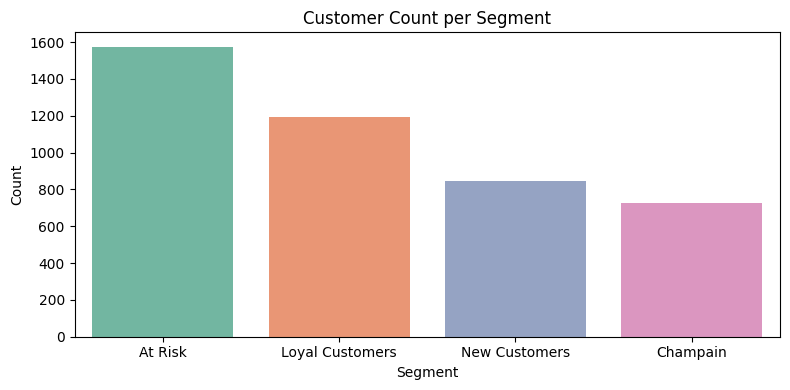

In [40]:
plt.figure(figsize=(8, 4))
sns.countplot(data=rfm, x='Segment',
              order=rfm['Segment'].value_counts().index,
              palette='Set2')
plt.title('Customer Count per Segment')
plt.xlabel('Segment')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

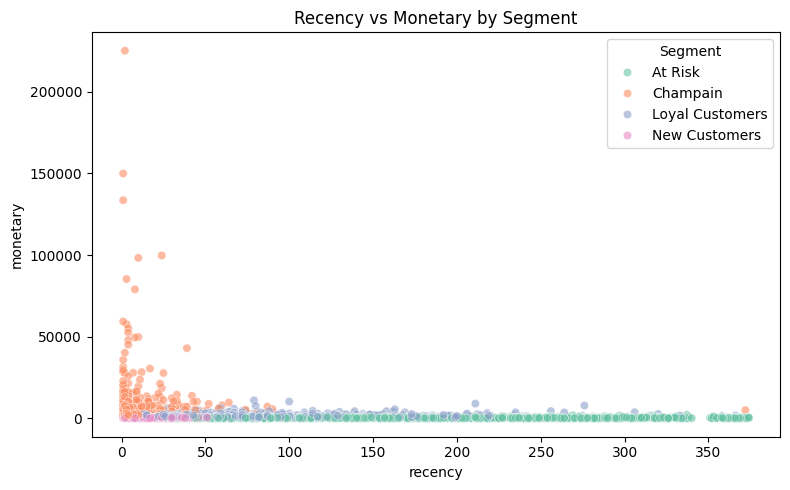

In [41]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=rfm, x='recency', y='monetary',
                hue='Segment', palette='Set2', alpha=0.6)
plt.title('Recency vs Monetary by Segment')
plt.tight_layout()
plt.show()

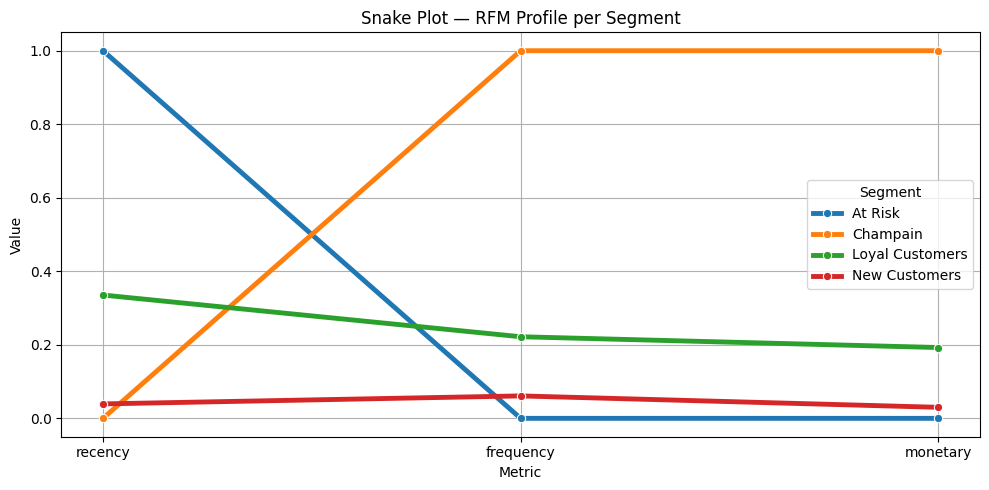

In [42]:
rfm_melted = rfm.groupby('Segment')[['recency','frequency','monetary']].mean()
rfm_melted = (rfm_melted - rfm_melted.min()) / (rfm_melted.max() - rfm_melted.min())
rfm_melted = rfm_melted.reset_index().melt(id_vars='Segment',
                                            var_name='Metric',
                                            value_name='Value')

plt.figure(figsize=(10, 5))
sns.lineplot(data=rfm_melted, x='Metric', y='Value',
             hue='Segment', marker='o', linewidth=3.5)
plt.title('Snake Plot — RFM Profile per Segment')
plt.grid(True)
plt.tight_layout()
plt.show()